In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import files
import sklearn
from sklearn.model_selection import train_test_split
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import seaborn as sns

In [2]:
pip install ISLP

In [3]:
from ISLP.models import (ModelSpec as MS, summarize, poly)
from ISLP import load_data
from ISLP import confusion_table

In [4]:
uploaded = files.upload()
data = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df = pd.DataFrame(data)
df

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (1).csv


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [5]:
def remove_outliers(df,column):
  filtered_pred = pd.DataFrame()
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  filtered_pred = df[column][(df[column] >= lower_bound) & (df[column] <= upper_bound)]
  return filtered_pred

In [6]:
predictors = df.columns.drop(['DEATH_EVENT','time'])
for i in predictors:
  df[i] = remove_outliers(df,i)
df.dropna(inplace = True)
X = df.columns.drop(['DEATH_EVENT','time','anaemia','diabetes','high_blood_pressure','sex','smoking']) #dropped boolean predictors bc it doesn't make sense
X = df[X]
X = (X - X.mean())/X.std()
X_boolean = df[['anaemia','diabetes','high_blood_pressure','sex','smoking']]
X = pd.concat([X,X_boolean],axis = 1)
X['DEATH_EVENT'] = df['DEATH_EVENT']
std_df = pd.DataFrame(X)
std_columns = std_df.columns

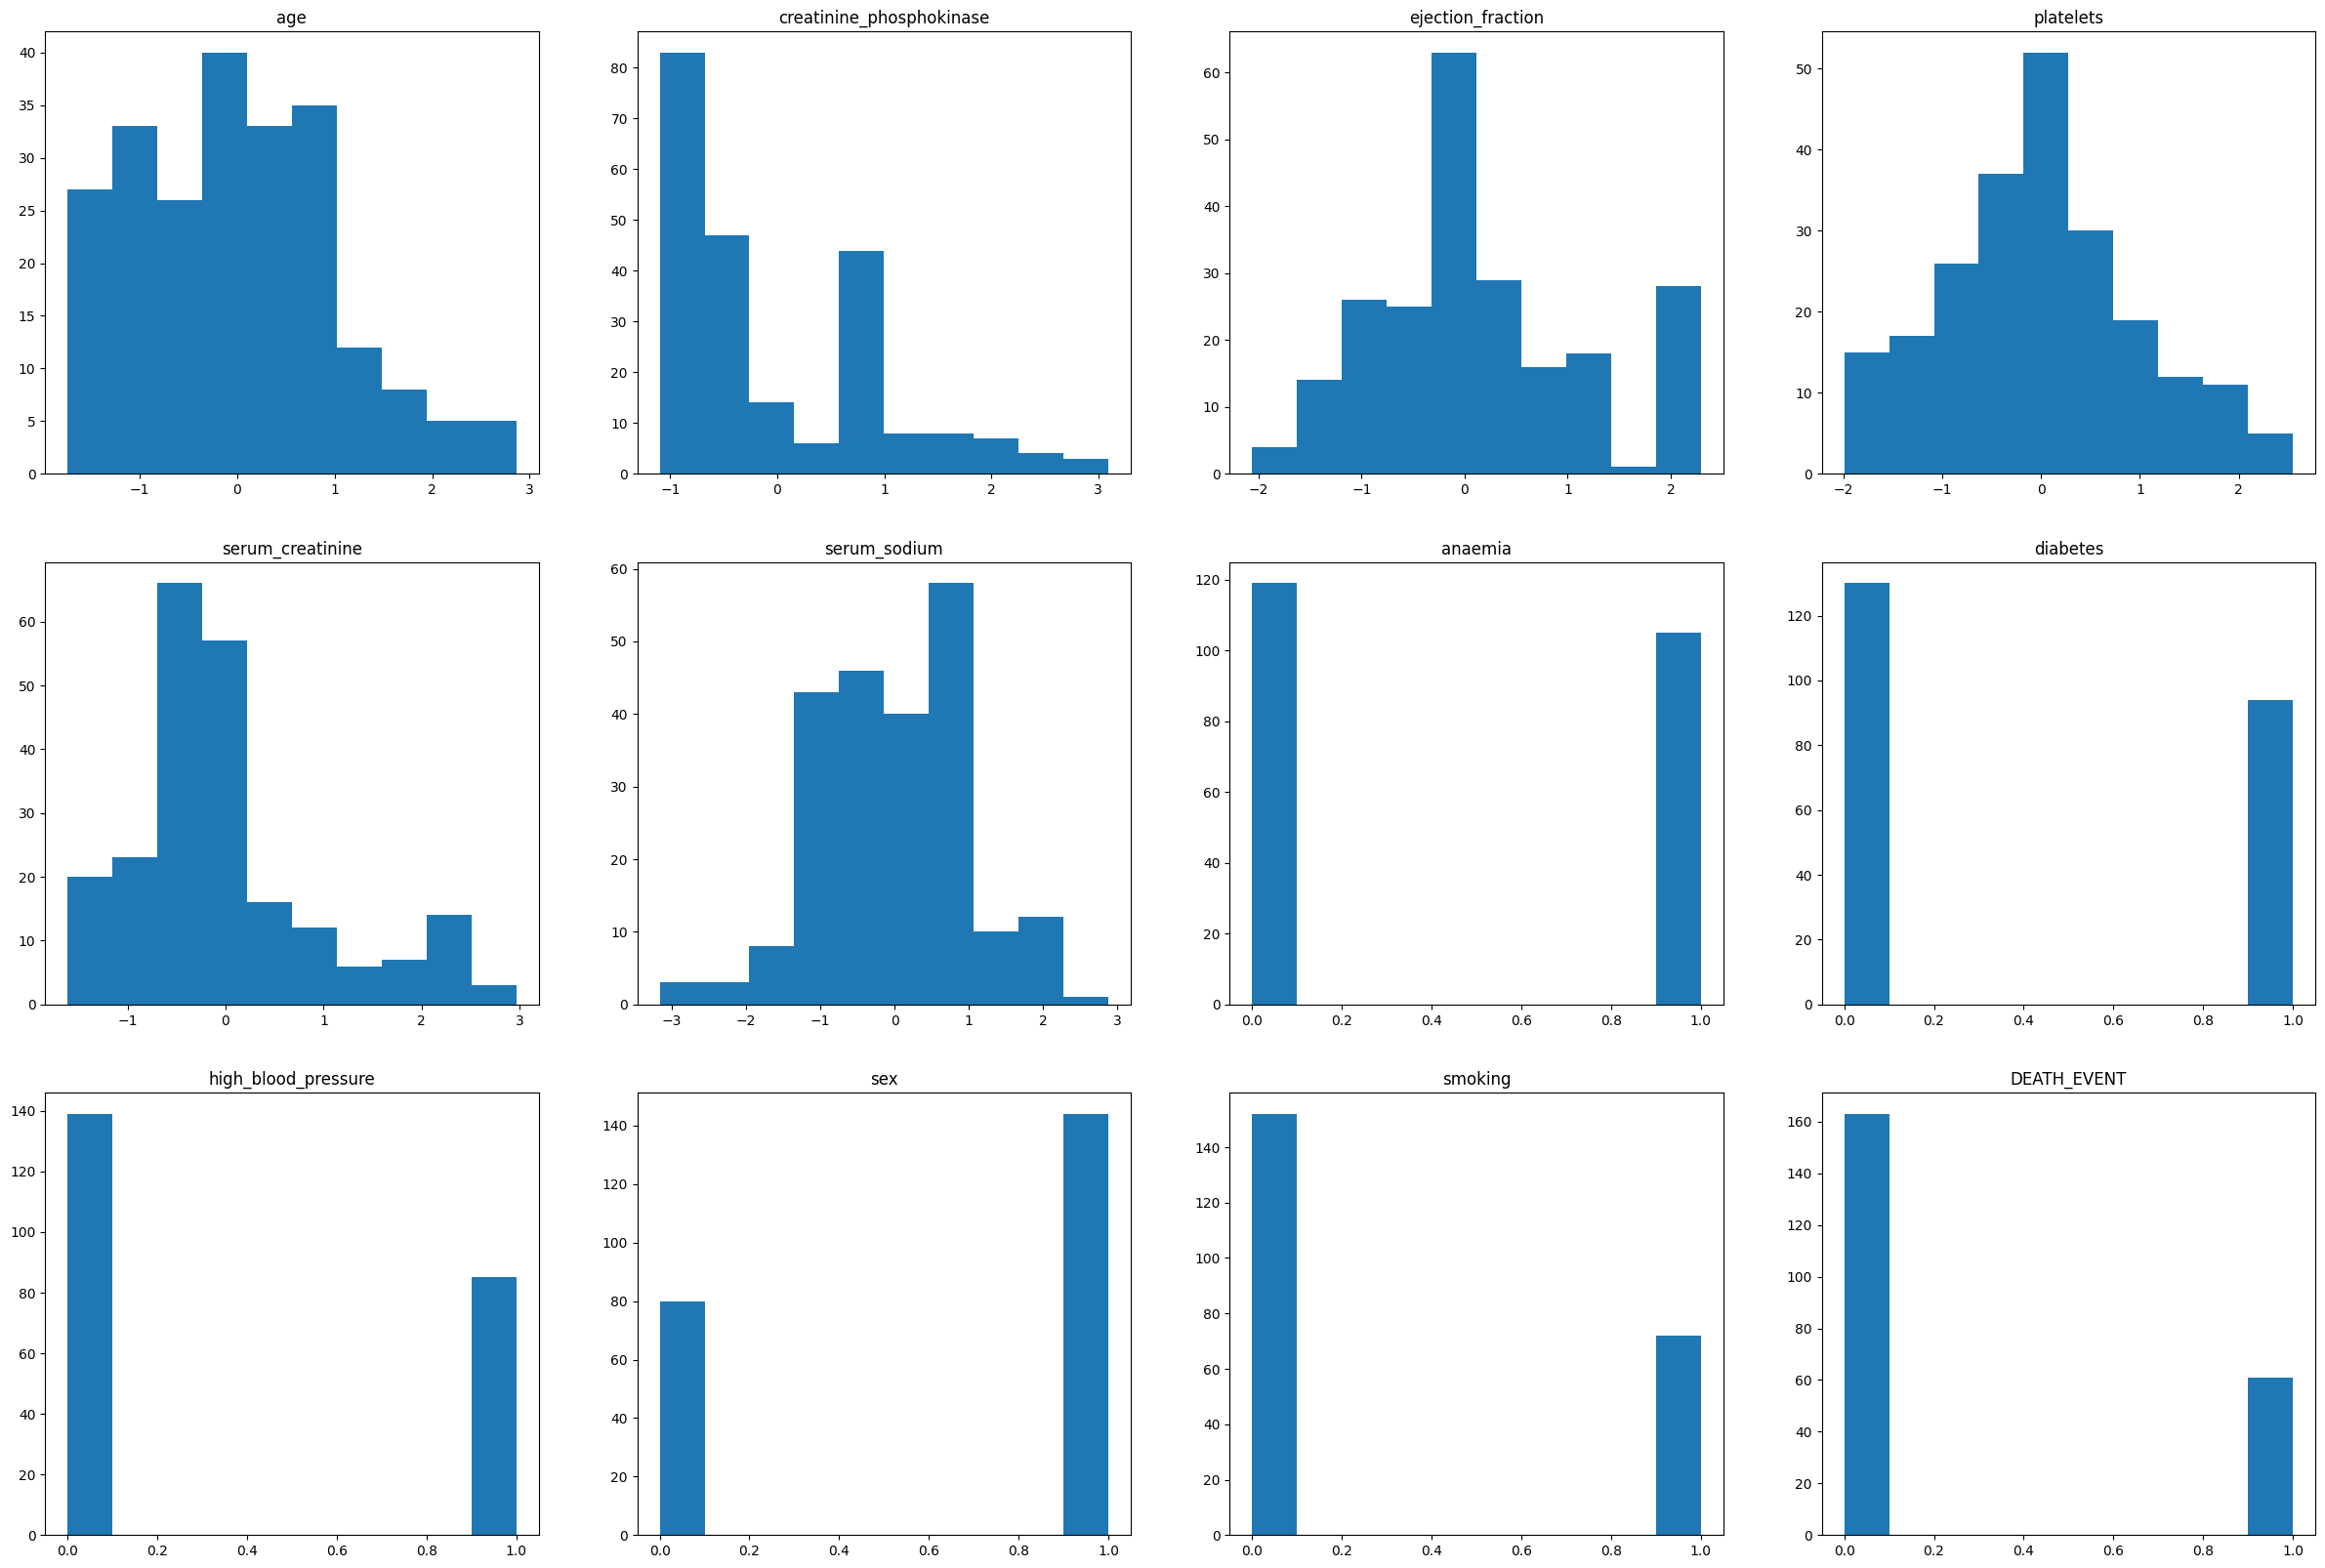

In [66]:
fig,ax = plt.subplots(3,4,figsize = (30,20))
for i,j in enumerate(std_columns):
  ax[i//4,i%4].hist(std_df[j])
  ax[i//4,i%4].set_title(j)
saved_file = 'histograms.png'
fig.savefig(saved_file)

In [8]:
train,test = train_test_split(std_df,test_size = 0.2,random_state = 0)

In [30]:
predictors = MS(std_df.columns.drop('DEATH_EVENT'))
design = predictors.fit_transform(df)
model = sm.GLM(df['DEATH_EVENT'], design, family=sm.families.Binomial())
results = model.fit()
results.pvalues

,0
intercept,0.863274
age,0.000371
creatinine_phosphokinase,0.996154
ejection_fraction,0.000066
platelets,0.571257
serum_creatinine,0.000832
serum_sodium,0.649955
anaemia,0.207832
diabetes,0.690731
high_blood_pressure,0.214317


logistic regression curve:

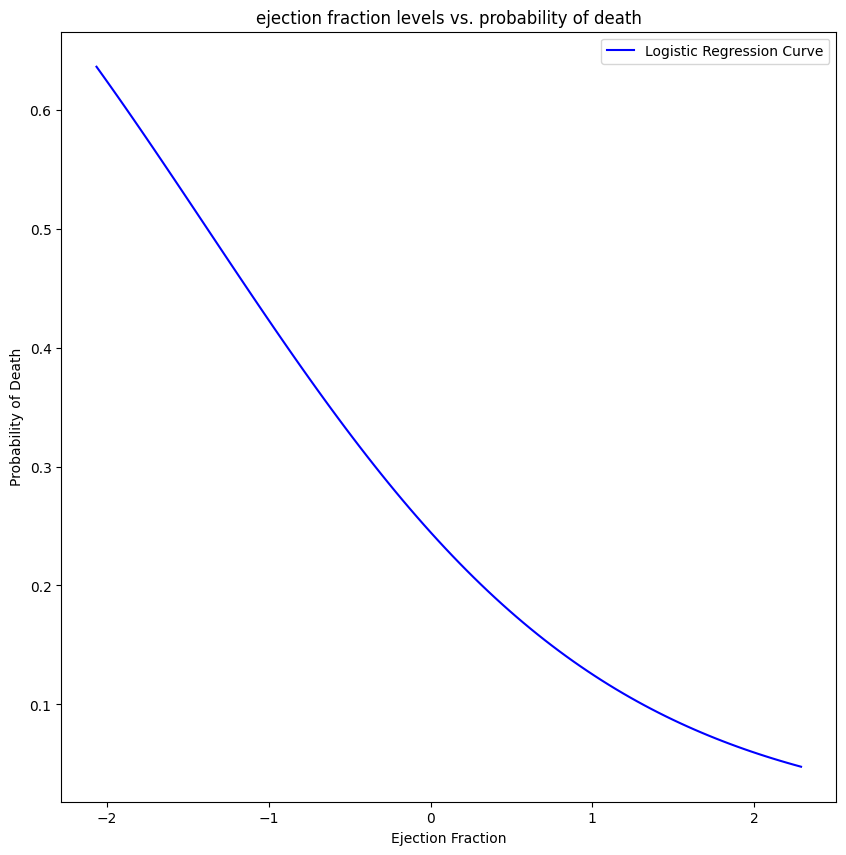

In [83]:
predictors = MS(['ejection_fraction'])
design = predictors.fit_transform(std_df)
model = sm.GLM(df['DEATH_EVENT'], design, family=sm.families.Binomial())
results = model.fit()
x_space = np.linspace(std_df['ejection_fraction'].min(),std_df['ejection_fraction'].max(),100).reshape(-1,1)
y_space = results.predict(exog=predictors.fit_transform(pd.DataFrame(x_space, columns=['ejection_fraction'])))
fig,ax = plt.subplots(figsize = (10,10))
plt.plot(x_space, y_space, color='b', label='Logistic Regression Curve')
ax.set_xlabel('Ejection Fraction')
ax.set_ylabel('Probability of Death')
ax.set_title('ejection fraction levels vs. probability of death')
ax.legend()
plt.savefig('logistic_regression_curve.png')

results for model with all predictors:


In [31]:
confusion_table(df['DEATH_EVENT'],results.predict(design).round())

Truth,0.0,1.0
Predicted,,
0.0,151,12
1.0,32,29


results for model with just relevant predictors:

In [32]:
predictors = MS(std_df[['age','ejection_fraction','serum_creatinine']])
design = predictors.fit_transform(std_df)
model = sm.GLM(std_df['DEATH_EVENT'], design, family=sm.families.Binomial())
results = model.fit()
confusion_table(std_df['DEATH_EVENT'],results.predict(design).round())

Truth,0.0,1.0
Predicted,,
0.0,152,11
1.0,34,27


most of the correlation with death event is explained by these 3 predictors

**Logistic regression with the lasso**

First we have to scale the predictors and create training/test data

In [33]:
X = train.drop('DEATH_EVENT',axis = 1)
y = train['DEATH_EVENT']

In [34]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [35]:
X_train = pd.DataFrame(X_train,columns = train.columns.drop('DEATH_EVENT'))
X_test = pd.DataFrame(X_test,columns = train.columns.drop('DEATH_EVENT'))
y_train = pd.DataFrame(y_train,columns = ['DEATH_EVENT'])
y_test = pd.DataFrame(y_test,columns = ['DEATH_EVENT'])

In [52]:
kfold = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=10)

In [59]:
lassoCV = skl.ElasticNetCV(n_alphas=100,l1_ratio=1,cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),('lasso', lassoCV)])
pipeCV.fit(X_train, y_train)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.03513403505498033

In [85]:
lambdas, soln_array = skl.Lasso.path(X,y,l1_ratio=1,n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,
                         columns=X_train.columns,
                         index=np.log(lambdas))


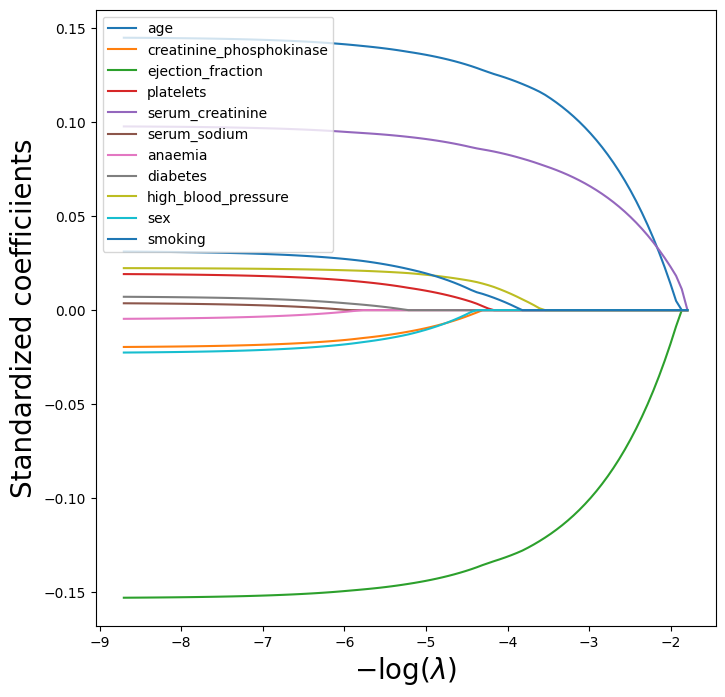

In [86]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficiients', fontsize=20);
path_fig.savefig('lasso_path.png')

creating the logostic regression model with the lasso:

In [87]:
y_train = y_train.reset_index(drop=True)
predictors = MS(X_train)
design = predictors.fit_transform(X_train).reset_index(drop = True)
model = sm.GLM(y_train, design, family=sm.families.Binomial())
results = model.fit_regularized(alpha = tuned_lasso.alpha_, refit = True)
results_df = pd.DataFrame({'params': results.params})
results_df

,params
0,-1.903989
1,1.116315
2,0.000000
3,-1.193549
4,0.000000
5,0.725733
6,0.000000
7,0.000000
8,0.000000
9,0.000000


based on the feature selection performed by the Lasso, the only important predictors for this model once again are age, serum creatitine, and ejection fraction. This confirms our belief.

In [88]:
confusion_table(y_test,results.predict(predictors.fit_transform(X_test)).round())

Truth,0.0,1.0
Predicted,,
0.0,32,2
1.0,13,7


test error rate: 27.78%
test correct classification rate:72.22%